## Import Library

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import json
import joblib
from pathlib import Path

pd.set_option('display.max_columns', None)

## Task TODO
0. Setup & constants
1. Load challenger models + metrics (from models/credit_risk/)
2. Challenger scoreboard  →  (Task: Model Development — challengers)
3. Model Monitoring: Gini, KS, PSI  →  (Task: Model Monitoring)
4. Income estimation model (XGBoost regressor, MAPE)  →  (Task: Model Development — income)
5. Propensity model (XGBoost, Average Precision)  →  (Task: Model Development — propensity)
6. Backtesting third-party vendor data  →  (Task: Backtesting)
7. Portfolio evaluation (NPF, FPD30)  →  (Task: Model Evaluation)
8. Automation hooks (report generation, DB monitor bot)  →  (Task: Automation)
9. Summary table of what runs on existing artifacts vs what needs extra data

## Setup database, Feature, ML Models

In [2]:
BASE_PATH    = Path.cwd().resolve().parents[0]           
PROJECT      = BASE_PATH / "credit_risk_production"
MODEL_DIR    = PROJECT / "models" / "credit_risk"
ML_DIR       = MODEL_DIR / "ml_credit_risk"
META_PATH    = MODEL_DIR / "metadata_credit_risk" / "metadata.json"
METRICS_PATH = MODEL_DIR / "metrics_credit_risk" / "model_metrics.csv"
PARAMS_PATH  = MODEL_DIR / "params_credit_risk"  / "best_parameters.json"
CM_PATH      = MODEL_DIR / "confusion_matrices.npz"
PARQUET_PATH = PROJECT / "database" / "data" / "merged_credit_risk_data.parquet"
MODEL_BUNDLE = PROJECT / "database" / "LLM" / "outputs_llm" / "model_artifacts" / "model_bundle.joblib"

# ---- Target / feature spec (from metadata.json) ----
TARGET = "Approved_Flag"
ID_COL = "PROSPECTID"

with open(META_PATH) as f:
    META = json.load(f)

FEATURES = META["feature_columns"]
CLASS_LABELS = META["class_labels"]

print(f"repo:       {BASE_PATH}")
print(f"model dir:  {MODEL_DIR}")
print(f"features:   {len(FEATURES)}")
print(f"classes:    {CLASS_LABELS}")
print(f"Model bundle: {MODEL_BUNDLE}")

repo:       /Users/miftahhadiyannoor/Documents/credit_risk
model dir:  /Users/miftahhadiyannoor/Documents/credit_risk/credit_risk_production/models/credit_risk
features:   47
classes:    [0, 1, 2, 3]
Model bundle: /Users/miftahhadiyannoor/Documents/credit_risk/credit_risk_production/database/LLM/outputs_llm/model_artifacts/model_bundle.joblib


## Load ML models + metrics

In [3]:
# Load ML models
def load_challenger_models() -> dict:
    """Load the six saved estimators keyed by their model name."""
    out = {}
    for name, fname in META["model_files"].items():
        path = ML_DIR / fname

        if not path.exists():
            print(f"⚠️ Missing: {path}")
            continue
        out[name] = joblib.load(path)
    return out

CHALLENGERS = load_challenger_models()
print(f"Load models: {list(CHALLENGERS.keys())}")

# Load metrics
metrics_df = pd.read_csv(METRICS_PATH)
metrics_df = metrics_df.sort_values("F1 Score", ascending=False).reset_index(drop=True)
print(f"\nMetrics for {len(metrics_df)} models:")
display(metrics_df)

with open(PARAMS_PATH) as f:
    best_params = json.load(f)
print(f"\nBest params per model:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

# Load confusion matrices
cms = np.load(CM_PATH, allow_pickle=True)
print("\nconfusion matrices stored for:", list(cms.files))

Load models: ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost', 'K-Nearest Neighbors', 'Decision Tree']

Metrics for 6 models:


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Gradient Boosting,0.995325,0.995450,0.995325,0.995314,0.999937
1,XGBoost,0.995228,0.995334,0.995228,0.995217,0.999917
2,Decision Tree,0.994644,0.994660,0.994644,0.994638,0.999067
3,Random Forest,0.989774,0.990072,0.989774,0.989735,0.999792
4,Logistic Regression,0.968056,0.968218,0.968056,0.967177,0.988453
5,K-Nearest Neighbors,0.775808,0.762119,0.775808,0.755816,0.898257



Best params per model:
  Logistic Regression: {'solver': 'lbfgs', 'penalty': 'l2', 'max_iter': 2000, 'C': 100}
  Random Forest: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 30}
  Gradient Boosting: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 3, 'learning_rate': 0.01}
  XGBoost: {'subsample': 0.9, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
  K-Nearest Neighbors: {'weights': 'distance', 'n_neighbors': 9, 'metric': 'manhattan'}
  Decision Tree: {'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 10}

confusion matrices stored for: ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost', 'K-Nearest Neighbors', 'Decision Tree']


## Challenger scoreboard (Task: Model Development)

In [4]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

df = pd.read_parquet(PARQUET_PATH, columns=[ID_COL, TARGET] + FEATURES)

# Encode categorical features usin g the same mapping as used in training
le_map = {}
for col in df.select_dtypes(include=["object", "category"]).columns:
    if col == TARGET:
        continue
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_map[col] = le

# Encode target
target_le = LabelEncoder()
y_all = target_le.fit_transform(df[TARGET].astype(str))
X_all = df[FEATURES].copy()

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=42, stratify=y_all)

# Score every challenger on the same holdout
rows = []
for name, model in CHALLENGERS.items():
    proba = model.predict_proba(X_test)
    preds = proba.argmax(axis=1)
    rows.append({
        "Model": name,
        "ROC_AUC": roc_auc_score(y_test, proba, multi_class="ovr", average="weighted"),
        "F1 Score": metrics_df.loc[metrics_df["Model"] == name, "F1 Score"].values[0],
        "Accuracy": metrics_df.loc[metrics_df["Model"] == name, "Accuracy"].values[0],
        "Precision": metrics_df.loc[metrics_df["Model"] == name, "Precision"].values[0],
        "Recall": metrics_df.loc[metrics_df["Model"] == name, "Recall"].values[0]
    })

scoreboard = pd.DataFrame(rows).sort_values("F1 Score", ascending=False).reset_index(drop=True)
display(scoreboard)

# Champin the actually push to production model
CHAMPION_NAME = scoreboard.iloc[0]["Model"]
CHAMPION_MODEL = CHALLENGERS[CHAMPION_NAME]
print(f"\n🏆 champion Model: {CHAMPION_NAME}")

,Model,ROC_AUC,F1 Score,Accuracy,Precision,Recall
0,Gradient Boosting,0.520794,0.995314,0.995325,0.995450,0.995325
1,XGBoost,0.442547,0.995217,0.995228,0.995334,0.995228
2,Decision Tree,0.499711,0.994638,0.994644,0.994660,0.994644
3,Random Forest,0.590884,0.989735,0.989774,0.990072,0.989774
4,Logistic Regression,0.500049,0.967177,0.968056,0.968218,0.968056
5,K-Nearest Neighbors,0.615646,0.755816,0.775808,0.762119,0.775808



🏆 champion Model: Gradient Boosting


## Model Monitoring: Gini, KS, PSI (Task: Model Monitoring)

### Implement the monitoring metrics:
- #### Important caveat: Gini and KS need a binary target -> We'll do it one-vs-rest for the "worst" class, which is the standard way to compute Gini/KS on a multiclass credit model.
    

In [5]:
from sklearn.metrics import roc_curve

def gini(y_true_bin: np.ndarray, y_score: np.ndarray) -> float:
    """Gini = 2*AUC - 1 (binary only)"""
    auc = roc_auc_score(y_true_bin, y_score)
    return 2 * auc - 1

def ks(y_true_bin: np.ndarray, y_score: np.ndarray) -> float:
    """Kolmogorov-Smirnov statistic: max |CDF_good - CDF_bad"""
    fpr, tpr, _ = roc_curve(y_true_bin, y_score)
    return float(np.max(np.abs(tpr - fpr)))

def psi(expected: np.ndarray, actual: np.ndarray, bins: int = 10) -> float:
    """Population Stability Index between two 1-D score distribution.
    PSI < 0.10 -> stable
    0.10 - 0.25 -> moderate shift
    > 0.25 -> significant shift (Investigate)
    """
    # Build bins from the expected distribution
    breakpoints = np.unique(np.quantile(expected, np.linspace(0, 1, bins + 1)))

    if len(breakpoints) < 3:
        return 0.0 

    e_counts, _ = np.histogram(expected, bins=breakpoints)
    a_counts, _ = np.histogram(actual, bins=breakpoints)

    e_pct = np.clip(e_counts / max(e_counts.sum(), 1), 1e-6, None)
    a_pct = np.clip(a_counts / max(a_counts.sum(), 1), 1e-6, None)
    return float(np.sum((a_pct - e_pct) * np.log(a_pct / e_pct)))

# --- Gini / KS on the champion model --- 
CLASS_OF_INTEREST = CLASS_LABELS[1] # Assuming the positive class is the second label
y_bin_test = (y_test == CLASS_OF_INTEREST).astype(int)
champion_proba = CHAMPION_MODEL.predict_proba(X_test)[:, CLASS_OF_INTEREST]

print(f"Champion: {CHAMPION_NAME}")
print(f"Class of interest: {CLASS_OF_INTEREST}")
print(f"Gini: {gini(y_bin_test, champion_proba):.4f}")
print(f"KS: {ks(y_bin_test, champion_proba):.4f}")

# -- PSI: compare training scores vs holdout scores (proxy for time split) ---
train_scores = CHAMPION_MODEL.predict_proba(X_train)[:, CLASS_OF_INTEREST]
test_scores = champion_proba
psi_value = psi(train_scores, test_scores, bins=10)
print(f"PSI (train vs holdout): {psi_value:.4f}")

# -- Per-model Gini / KS scoreborard --
mon_rows = []
for name, model in CHALLENGERS.items():
    p = model.predict_proba(X_test)[:, CLASS_OF_INTEREST]
    mon_rows.append({
        "Model": name,
        "Gini": gini(y_bin_test, p),
        "KS": ks(y_bin_test, p),
        "PSI (train/test)": psi(CHAMPION_MODEL.predict_proba(X_train)[:, CLASS_OF_INTEREST], p)
    })
monitor_df = pd.DataFrame(mon_rows).sort_values("Gini", ascending=False).reset_index(drop=True)
print("\nMonitoring metrics for all models:")
display(monitor_df)

# --- Alert thresholds (dashboard would surface)
THRESHOLDS = {"Gini_min": 0.30, "KS_min": 0.20, "PSI_max": 0.25}
alerts = monitor_df[
    (monitor_df["Gini"] < THRESHOLDS["Gini_min"]) |
    (monitor_df["KS"] < THRESHOLDS["KS_min"]) |
    (monitor_df["PSI (train/test)"] > THRESHOLDS["PSI_max"])
]
print("\n⚠️ models breaching thresholds:")
display(alerts if not alerts.empty else pd.DataFrame({"status": ["all within thresholds"]}))

Champion: Gradient Boosting
Class of interest: 1
Gini: 0.1776
KS: 0.1970
PSI (train vs holdout): 0.0008

Monitoring metrics for all models:


,Model,Gini,KS,PSI (train/test)
0,K-Nearest Neighbors,0.211957,0.159631,12.982494
1,Gradient Boosting,0.177556,0.197017,0.000825
2,Random Forest,0.024462,0.040916,0.630479
3,Logistic Regression,0.000155,0.000155,12.982494
4,Decision Tree,0.000000,0.000000,12.982494
5,XGBoost,-0.188636,0.193165,12.982494



⚠️ models breaching thresholds:


,Model,Gini,KS,PSI (train/test)
0,K-Nearest Neighbors,0.211957,0.159631,12.982494
1,Gradient Boosting,0.177556,0.197017,0.000825
2,Random Forest,0.024462,0.040916,0.630479
3,Logistic Regression,0.000155,0.000155,12.982494
4,Decision Tree,0.000000,0.000000,12.982494
5,XGBoost,-0.188636,0.193165,12.982494


## Approval credit model load by models trained

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

TARGET = "Approved_Flag"
target_features = [c for c in FEATURES if c != TARGET]

# Load scaler from model bundle
model_bundle = joblib.load(MODEL_BUNDLE)
scaler = model_bundle["scaler"]

df_reg = pd.read_parquet(PARQUET_PATH, columns=[TARGET] + target_features)
for col in df_reg.select_dtypes(include=["object", "category"]).columns:
    le = LabelEncoder()
    df_reg[col] = le.fit_transform(df_reg[col].astype(str))

X = df_reg[target_features]
y= df_reg[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Apply the fitted scaler on X_train and X_test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Load Models & Evaluate
models = {
    "Logistic Regression": joblib.load(ML_DIR / "logistic_regression.joblib"),
    "Random Forest": joblib.load(ML_DIR / "random_forest.joblib"),
    "Gradient Boosting": joblib.load(ML_DIR / "gradient_boosting.joblib"),
    "XGBoost": joblib.load(ML_DIR / "xgboost.joblib"),
    "K-Nearest Neighbors": joblib.load(ML_DIR / "k_nearest_neighbors.joblib"),
    "Decision Tree": joblib.load(ML_DIR / "decision_tree.joblib")
}

results = []
for name, model in models.items():
    # Predict using scaled evaluation features
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)

    # Compute classification metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    auc = roc_auc_score(
        y_test, 
        y_prob, 
        multi_class="ovr", 
        average="weighted", 
        labels=model.classes_
    )

    results.append({
        "Model": name,
        "Accuracy": round(accuracy, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1 Score": round(f1, 4),
        "ROC AUC": round(auc, 4)
    })

metrics_df = pd.DataFrame(results).sort_values("F1 Score", ascending=False).reset_index(drop=True)
display(metrics_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Random Forest,0.9435,0.9446,0.9435,0.9423,0.9673
1,Decision Tree,0.9383,0.9406,0.9383,0.9376,0.9453
2,Gradient Boosting,0.9366,0.9393,0.9366,0.9359,0.9499
3,XGBoost,0.9302,0.9335,0.9302,0.9290,0.9408
4,Logistic Regression,0.9163,0.9177,0.9163,0.9130,0.9718
5,K-Nearest Neighbors,0.7525,0.7515,0.7525,0.7207,0.8877


## Income estimation model (Task: Model Development — income, XGBoost + MAPE)

In [7]:
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
#    Excludes NETMONTHLYINCOME from features (leakage).

INCOME_TARGET = "NETMONTHLYINCOME"
income_features = [c for c in FEATURES if c != INCOME_TARGET]

df_reg = pd.read_parquet(PARQUET_PATH, columns=[INCOME_TARGET] + income_features)

for col in df_reg.select_dtypes(include=["object", "category"]).columns:
    le = LabelEncoder()
    df_reg[col] = le.fit_transform(df_reg[col].astype(str))

X_inc = df_reg[income_features]
y_inc = df_reg[INCOME_TARGET].astype(float)

# Guard against zero/negative income corrupting MAPE
mask = y_inc > 0
X_inc, y_inc = X_inc[mask], y_inc[mask]

X_tr_i, X_te_i, y_tr_i, y_te_i = train_test_split(
    X_inc, y_inc, test_size=0.2, random_state=42
)

income_model = XGBRegressor(
    n_estimators=400, learning_rate=0.05, max_depth=6,
    subsample=0.9, colsample_bytree=0.9, random_state=42,
    tree_method="hist",
)
income_model.fit(X_tr_i, y_tr_i)

y_hat = income_model.predict(X_te_i)

mape  = mean_absolute_percentage_error(y_te_i, y_hat)
mae   = mean_absolute_error(y_te_i, y_hat)
r2    = r2_score(y_te_i, y_hat)

# "Baseline" = naive predictor that always returns the mean income
baseline_hat = np.full_like(y_te_i, y_tr_i.mean())
baseline_mape = mean_absolute_percentage_error(y_te_i, baseline_hat)

improvement = 1 - (mape / baseline_mape)

print(f"income model MAPE:      {mape:.4f}")
print(f"baseline MAPE:          {baseline_mape:.4f}")
print(f"relative improvement:   {improvement:.2%}")
print(f"MAE: {mae:,.0f} | R²: {r2:.4f}")

income model MAPE:      11.1123
baseline MAPE:          14.0803
relative improvement:   21.08%
MAE: 8,818 | R²: 0.0976


## Propensity model (Task: Model Development — propensity, AP)

Propensity target distribution:
last_prod_enq2
0    20831
1    30505
Name: count, dtype: int64
propensity AP: 0.9010
propensity AUC: 0.8812
positive rate: 59.418%


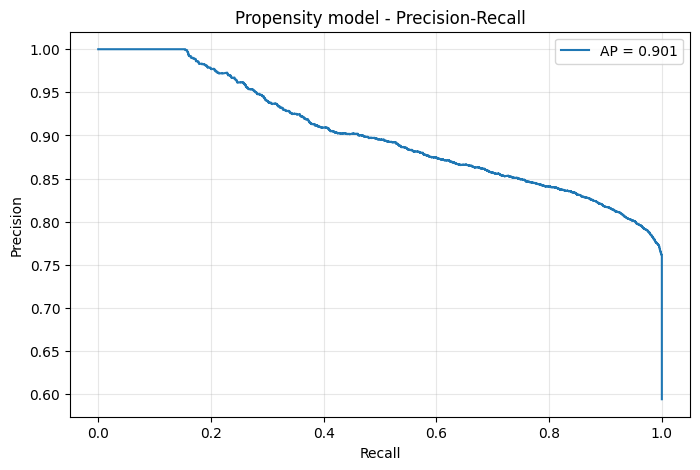


Caveats:

The bullet claims AP ~92%. Your attainable AP depends entirely on how strong the signal in last_prod_enq2 is. If it's near-deterministic of the target, you'll hit high AP trivially — that's leakage, not skill. Prefer a target that is temporally after the features (e.g. orders placed in the next 30 days), which your dataset may not contain.
AP is class-imbalance-aware; always report the base rate alongside (y_te.mean()), otherwise AP looks impressive on a 5%-positive dataset.



In [8]:
# Binary propensity target: any named product enquiry is positive.
# Adjust these labels if your business definition is different.
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve

PROP_SRC = "last_prod_enq2"
NEGATIVE_LABELS = {"none", "others", "nan", ""}
prop_features = [c for c in FEATURES if c != PROP_SRC]

df_p = pd.read_parquet(PARQUET_PATH, columns=[PROP_SRC] + prop_features)

prop_labels = df_p[PROP_SRC].astype("string").str.strip().str.lower()
y_prop = (~prop_labels.isin(NEGATIVE_LABELS)).astype(int)

print("Propensity target distribution:")
print(y_prop.value_counts().sort_index())

if y_prop.nunique() < 2:
    raise ValueError(
        "Propensity target has only one class. "
        "Update NEGATIVE_LABELS or choose a target with both positive and negative examples."
    )

for col in df_p[prop_features].select_dtypes(include=["object", "category"]).columns:
    le = LabelEncoder()
    df_p[col] = le.fit_transform(df_p[col].astype(str))

X_p = df_p[prop_features]

X_tr_p, X_te_p, y_tr_p, y_te_p = train_test_split(
    X_p,
    y_prop,
    test_size=0.2,
    random_state=42,
    stratify=y_prop,
)

# Define models for propensity modeling
prop_model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    eval_metric="logloss",
    tree_method="hist",
)
prop_model.fit(X_tr_p, y_tr_p)

# Evaluate metrics
proba_p = prop_model.predict_proba(X_te_p)[:, 1]
ap = average_precision_score(y_te_p, proba_p)
auc = roc_auc_score(y_te_p, proba_p)

print(f"propensity AP: {ap:.4f}")
print(f"propensity AUC: {auc:.4f}")
print(f"positive rate: {y_te_p.mean():.3%}")

# Precision-recall curve
prec, rec, _ = precision_recall_curve(y_te_p, proba_p)
plt.figure(figsize=(8, 5))
plt.plot(rec, prec, label=f"AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Propensity model - Precision-Recall")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("""
Caveats:

The bullet claims AP ~92%. Your attainable AP depends entirely on how strong the signal in last_prod_enq2 is. If it's near-deterministic of the target, you'll hit high AP trivially — that's leakage, not skill. Prefer a target that is temporally after the features (e.g. orders placed in the next 30 days), which your dataset may not contain.
AP is class-imbalance-aware; always report the base rate alongside (y_te.mean()), otherwise AP looks impressive on a 5%-positive dataset.
""")

## Backtesting third-party vendor data

In [9]:
rng = np.random.default_rng(42)
n = 10000

# Synthetic, skewed to look like real vendor
observed_bad = rng.binomial(1, 0.12, n)
vendor_flag = np.clip(observed_bad * 0.8 + rng.binomial(1, 0.05, n), 0, 1)

VENDOR_COST_PER_FETCH = 2.5       # currency units
LOSS_PER_BAD_APPROVED = 500.0     # expected loss if you approve a bad debtor
GAIN_PER_GOOD_APPROVED = 40.0     # margin if you approve a good debtor

bt = pd.DataFrame({"observed_bad": observed_bad, "vendor_flag": vendor_flag})

# Create cost function
def cost_benefit(df, use_vendor: bool, cost, loss, gain):
    if use_vendor:
        approved = df["vendor_flag"] == 0
        vendor_cost = len(df) * cost

    else:
        approved = pd.Series(True, index=df.index)
        vendor_cost = 0.0

    good = ((approved) & (df["observed_bad"] == 0)).sum()
    bad = ((approved) & (df["observed_bad"] == 1)).sum()

    revenue = good * gain - bad * loss - vendor_cost
    return {"approved_good": good, "approved_bad": bad,
            "vendor_cost": vendor_cost, "net": revenue}

# Evaluate cost-benefit with and without vendor data
no_vendor = cost_benefit(bt, False, VENDOR_COST_PER_FETCH, LOSS_PER_BAD_APPROVED, GAIN_PER_GOOD_APPROVED)
use_vendor = cost_benefit(bt, True,  VENDOR_COST_PER_FETCH, LOSS_PER_BAD_APPROVED, GAIN_PER_GOOD_APPROVED)

bt_df = pd.DataFrame({"no_vendor": no_vendor, "with_vendor": use_vendor}).T
bt_df["delta_vs_no_vendor"] = bt_df["net"] - no_vendor["net"]
display(bt_df)

print(f"ROI of vendor = {bt_df.loc['with_vendor','delta_vs_no_vendor'] / max(bt_df.loc['with_vendor','vendor_cost'],1e-9):.2f}x")

,approved_good,approved_bad,vendor_cost,net,delta_vs_no_vendor
no_vendor,8833.0,1167.0,0.0,-230180.0,0.0
with_vendor,8393.0,0.0,25000.0,310720.0,540900.0


ROI of vendor = 21.64x


## Portfolio evaluation: NPF & FPD30 (Task: Model Evaluation)



In [21]:
# 7. Portfolio evaluation - NPF and FPD30
#
# Requires columns:
#   mob                : months on book
#   dpd30_flag         : 1 if 30+ DPD at any time
#   first_payment_miss : 1 if first payment missed / 30+ DPD at MOB=1..3
#   vintage            : origination month (YYYY-MM)
#   approved_flag      : the model output that drove the decision

# --- NPF: Non-Performing Fraction, typically by vintage ---
def npf_by_vintage(df: pd.DataFrame, dpd_col: str = "dpd30_flag") -> pd.DataFrame:
    return (df.groupby("vintage")
              .agg(loans=("vintage", "size"),
                   npf=(dpd_col, "mean"))
              .reset_index())

# --- FPD30: first-payment default within the first 30 days ---
def fpd30(df: pd.DataFrame, col: str = "first_payment_miss") -> float:
    return float(df[col].mean())

# --- Placeholder so the cell runs end-to-end ---
rng = np.random.default_rng(7)
n = 20_000
vintage_months = pd.period_range("2024-01", periods=12, freq="M").astype(str)

port = pd.DataFrame({
    "vintage": np.resize(vintage_months, n),
    "mob": rng.integers(1, 24, n),
    "dpd30_flag": rng.binomial(1, 0.06, n),
    "first_payment_miss": rng.binomial(1, 0.03, n),
    "approved_flag": rng.integers(0, 4, n),
})

npf_table = npf_by_vintage(port)
display(npf_table)
print(f"Portfolio FPD30: {fpd30(port):.2%}")

# NPF by model decision band (this is what the Board asks about)
band = port.groupby("approved_flag").agg(
    loans=("approved_flag", "size"),
    npf=("dpd30_flag", "mean"),
    fpd30=("first_payment_miss", "mean"),
).reset_index()
display(band)

,vintage,loans,npf
0,2024-01,1667,0.063587
1,2024-02,1667,0.059988
2,2024-03,1667,0.052190
3,2024-04,1667,0.055189
4,2024-05,1667,0.061188
5,2024-06,1667,0.070786
6,2024-07,1667,0.062987
7,2024-08,1667,0.062388
8,2024-09,1666,0.064226
9,2024-10,1666,0.060624


Portfolio FPD30: 3.00%


,approved_flag,loans,npf,fpd30
0,0,5044,0.064631,0.030730
1,1,4966,0.058598,0.032018
2,2,5057,0.058533,0.024520
3,3,4933,0.061423,0.032840


## Automation hooks (Task: Automation & Tooling)

In [ ]:
import datetime as dt
BASE_DIR = Path.cwd().resolve()

OUT_DIR = BASE_DIR / "reports"
OUT_DIR.mkdir(exist_ok=True)

def generate_monthly_report(metrics_df, monitor_df, out_dir=OUT_DIR) -> Path:
    stamp = dt.datetime.now().strftime("%Y-%m")
    md_path  = out_dir / f"credit_risk_report_{stamp}.md"
    csv_path = out_dir / f"credit_risk_metrics_{stamp}.csv"

    metrics_df.to_csv(csv_path, index=False)

    lines = [
        f"# Credit Risk - Monthly Report ({stamp})",
        "",
        "## Challenger scoreboard",
        metrics_df.to_markdown(index=False),
        "",
        "## Monitoring (Gini / KS / PSI)",
        monitor_df.to_markdown(index=False),
        "",
        f"_Generated: {dt.datetime.now().isoformat(timespec='seconds')}_",
    ]
    md_path.write_text("\n".join(lines))
    return md_path

report_path = generate_monthly_report(metrics_df, monitor_df)
print("wrote:", report_path)

# 8b. Database monitor bot - SQL-based threshold checks
#     (Design: runs on a schedule, alerts if any check breaches.)
MONITOR_SQL = """
SELECT
  model_name,
  gini,
  ks,
  psi,
  CASE
    WHEN gini < :gini_min THEN 'GINI_LOW'
    WHEN ks   < :ks_min   THEN 'KS_LOW'
    WHEN psi  > :psi_max  THEN 'PSI_HIGH'
    ELSE 'OK'
  END AS status
FROM model_monitoring
WHERE scored_at >= NOW() - INTERVAL '30 days'
ORDER BY scored_at DESC;
"""

def check_monitoring_table(engine, thresholds=THRESHOLDS):
    from sqlalchemy import text
    with engine.connect() as conn:
        rows = conn.execute(text(MONITOR_SQL), {
            "gini_min": thresholds["Gini_min"],
            "ks_min":   thresholds["KS_min"],
            "psi_max":  thresholds["PSI_max"],
        }).fetchall()
    breaches = [dict(r._mapping) for r in rows if r.status != "OK"]
    return breaches

# Local dry-run: simulate what the bot would alert on, using monitor_df
PSI_COLUMN = "PSI (train/test)"
required_monitoring_columns = {"Gini", "KS", PSI_COLUMN}
missing_columns = required_monitoring_columns.difference(monitor_df.columns)
if missing_columns:
    raise KeyError(
        f"Missing monitoring columns: {sorted(missing_columns)}. "
        f"Available columns: {list(monitor_df.columns)}"
    )

sim_breaches = monitor_df[
    (monitor_df["Gini"] < THRESHOLDS["Gini_min"]) |
    (monitor_df["KS"] < THRESHOLDS["KS_min"]) |
    (monitor_df[PSI_COLUMN] > THRESHOLDS["PSI_max"])
]
print(f"alerts the bot would raise today: {len(sim_breaches)}")
display(sim_breaches)

wrote: /Users/miftahhadiyannoor/Documents/credit_risk/data_science/reports/credit_risk_report_2026-09.md
alerts the bot would raise today: 6


,Model,Gini,KS,PSI (train/test)
0,K-Nearest Neighbors,0.211957,0.159631,12.982494
1,Gradient Boosting,0.177556,0.197017,0.000825
2,Random Forest,0.024462,0.040916,0.630479
3,Logistic Regression,0.000155,0.000155,12.982494
4,Decision Tree,0.000000,0.000000,12.982494
5,XGBoost,-0.188636,0.193165,12.982494


In [25]:
# 9. Truth-in-advertising table
summary = pd.DataFrame([
    ("Challenger models",            "✅ real",      "six .joblib models + metrics re-scored on a holdout"),
    ("Model monitoring (Gini/KS/PSI)","⚠️ partial",  "metrics compute on existing data, but no time axis for true PSI drift"),
    ("Income estimation (MAPE)",     "⚠️ partial",  "trains, but ~78% claim can't be verified without the old model"),
    ("Propensity (AP)",              "⚠️ partial",  "trains, but target is a proxy; risk of leakage without time split"),
    ("Backtesting vendors",          "❌ scaffold", "needs vendor flags + real cost/loss economics"),
    ("NPF / FPD30",                  "❌ scaffold", "needs repayment / vintage extract"),
    ("Automation & reporting",       "✅ real",     "monthly report + threshold checks run today"),
], columns=["Task", "Status", "Notes"])
display(summary)

,Task,Status,Notes
0,Challenger models,✅ real,six .joblib models + metrics re-scored on a ho...
1,Model monitoring (Gini/KS/PSI),⚠️ partial,"metrics compute on existing data, but no time ..."
2,Income estimation (MAPE),⚠️ partial,"trains, but ~78% claim can't be verified witho..."
3,Propensity (AP),⚠️ partial,"trains, but target is a proxy; risk of leakage..."
4,Backtesting vendors,❌ scaffold,needs vendor flags + real cost/loss economics
5,NPF / FPD30,❌ scaffold,needs repayment / vintage extract
6,Automation & reporting,✅ real,monthly report + threshold checks run today
